In [1]:
"""
===========================================================
Project : CPU Predictive Maintenance
Notebook: 07_inference.ipynb
Purpose
-------
Inference Pipeline
• Load trained models
• Load incoming CPU data
• Perform preprocessing
• Predict next 3 working hours
• Detect anomalies
• Save prediction results
Author : Avilasha Goswami
===========================================================
"""

'\n===========================================================\nProject : CPU Predictive Maintenance\nNotebook: 07_inference.ipynb\nPurpose\n-------\nInference Pipeline\n• Load trained models\n• Load incoming CPU data\n• Perform preprocessing\n• Predict next 3 working hours\n• Detect anomalies\n• Save prediction results\nAuthor : Avilasha Goswami\n===========================================================\n'

In [2]:
# ==========================================
# Imports
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt

In [3]:
# ==========================================
# Configuration
# ==========================================

LOOKBACK = 432              # Previous 36 Hours
FORECAST_HORIZON = 36       # Next 3 Hours

MODEL_DIR = Path("models")

DATA_PATH = Path(
    r"C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\inference_data\cpu_master_new.csv"
)

OUTPUT_DIR = Path("output")

OUTPUT_DIR.mkdir(exist_ok=True)

FEATURE_PATH = MODEL_DIR / "feature_columns.pkl"

print("Configuration Loaded")

Configuration Loaded


In [4]:
# ==========================================
# Load Feature Columns
# ==========================================

FEATURE_COLUMNS = joblib.load(FEATURE_PATH)

print("Feature Columns Loaded")

print(f"Total Features : {len(FEATURE_COLUMNS)}")

FEATURE_COLUMNS[:10]

Feature Columns Loaded
Total Features : 443


['cpu_lag_1',
 'cpu_lag_2',
 'cpu_lag_3',
 'cpu_lag_4',
 'cpu_lag_5',
 'cpu_lag_6',
 'cpu_lag_7',
 'cpu_lag_8',
 'cpu_lag_9',
 'cpu_lag_10']

In [5]:
# ==========================================
# Load Models
# ==========================================

forecast_models = {

    1: joblib.load(
        MODEL_DIR / "xgb_3hour_model_server1.pkl"
    ),

    2: joblib.load(
        MODEL_DIR / "xgb_3hour_model_server2.pkl"
    ),

    3: joblib.load(
        MODEL_DIR / "xgb_3hour_model_server3.pkl"
    )

}

anomaly_models = {

    1: joblib.load(
        MODEL_DIR / "isolation_forest_server1.pkl"
    ),

    2: joblib.load(
        MODEL_DIR / "isolation_forest_server2.pkl"
    ),

    3: joblib.load(
        MODEL_DIR / "isolation_forest_server3.pkl"
    )

}

print("Forecast Models Loaded")

print("Isolation Forest Models Loaded")

Forecast Models Loaded
Isolation Forest Models Loaded


In [6]:
# ==========================================
# Load Incoming Data
# ==========================================

df = pd.read_csv(DATA_PATH)

print(df.shape)

df.head()

(17805, 13)


,id,ts,host_id,cpu_usage_pct,memory_usage_pct,power_kw,temperature_c,status,ilo_server_id,inlet_temp_c,cpu_temp_c,processor_count,hostName
0,74990,2026-06-12 00:01:00+00:00,2,1.28,21.65,0.256,25.0,Normal,2,25.0,44.0,2,10.10.10.150
1,74993,2026-06-12 00:06:00+00:00,2,1.92,21.65,0.257,27.0,Normal,2,27.0,45.0,2,10.10.10.150
2,74996,2026-06-12 00:11:00+00:00,2,1.23,21.65,0.210,26.0,Normal,2,26.0,44.0,2,10.10.10.150
3,74999,2026-06-12 00:16:00+00:00,2,2.23,21.65,0.208,21.0,Normal,2,21.0,42.0,2,10.10.10.150
4,75002,2026-06-12 00:21:00+00:00,2,1.33,21.65,0.210,23.0,Normal,2,23.0,42.0,2,10.10.10.150


In [7]:
# ==========================================
# Cleaning
# ==========================================

df["ts"] = pd.to_datetime(
    df["ts"],
    utc=True,
    format="mixed"
)

df = df.sort_values(
    ["host_id","ts"]
)

df.reset_index(
    drop=True,
    inplace=True
)

print(df.shape)

(17805, 13)


In [8]:
# ==========================================
# Working Hour Features
# ==========================================

df["hour_of_day"] = df["ts"].dt.hour

df["day_of_week"] = df["ts"].dt.dayofweek

df["is_weekend"] = (
    df["day_of_week"] == 6
).astype(int)

df["working_hour"] = 0

weekday_mask = (

    (df.day_of_week <= 4)

    &

    (df.hour_of_day >= 9)

    &

    (df.hour_of_day < 18)

)

saturday_mask = (

    (df.day_of_week == 5)

    &

    (df.hour_of_day >= 9)

    &

    (df.hour_of_day < 13)

)

df.loc[
    weekday_mask | saturday_mask,
    "working_hour"
] = 1

df.head()

,id,ts,host_id,cpu_usage_pct,memory_usage_pct,power_kw,temperature_c,status,ilo_server_id,inlet_temp_c,cpu_temp_c,processor_count,hostName,hour_of_day,day_of_week,is_weekend,working_hour
0,74989,2026-06-12 00:01:00+00:00,1,3.86,81.75,0.220,25.0,Warning,1,25.0,41.0,2,10.10.10.65,0,4,0,0
1,74992,2026-06-12 00:06:00+00:00,1,4.95,81.75,0.220,28.0,Warning,1,28.0,42.0,2,10.10.10.65,0,4,0,0
2,74995,2026-06-12 00:11:00+00:00,1,4.82,81.75,0.222,27.0,Warning,1,27.0,42.0,2,10.10.10.65,0,4,0,0
3,74998,2026-06-12 00:16:00+00:00,1,4.22,81.75,0.220,20.0,Warning,1,20.0,39.0,2,10.10.10.65,0,4,0,0
4,75001,2026-06-12 00:21:00+00:00,1,3.69,81.76,0.220,24.0,Warning,1,24.0,39.0,2,10.10.10.65,0,4,0,0


In [9]:
# ==========================================
# Keep Working Hours
# ==========================================

df = df[
    df["working_hour"] == 1
].copy()

print(df.shape)

(5112, 17)


In [10]:
# ==========================================
# Verify Input
# ==========================================

print(df["host_id"].unique())

print()

print(df.groupby("host_id").size())

print()

print(df.shape)

[1 2 3]

host_id
1    1704
2    1704
3    1704
dtype: int64

(5112, 17)


In [11]:
# ==========================================
# Run Inference for All Servers
# ==========================================

all_predictions = []

for server_id in sorted(df["host_id"].unique()):

    print("=" * 70)
    print(f"Processing Server {server_id}")

    # ----------------------------------------
    # Select Current Server
    # ----------------------------------------

    server_df = (
        df[df["host_id"] == server_id]
        .copy()
        .sort_values("ts")
        .reset_index(drop=True)
    )

    print(f"Rows Available : {len(server_df)}")

    # ----------------------------------------
    # Create Lag Features
    # ----------------------------------------

    for lag in range(1, LOOKBACK + 1):

        server_df[f"cpu_lag_{lag}"] = (
            server_df["cpu_usage_pct"].shift(lag)
        )

    # ----------------------------------------
    # Feature Engineering
    # ----------------------------------------

    server_df["cpu_change"] = (
        server_df["cpu_usage_pct"].diff()
    )

    server_df["cpu_roll_mean_3"] = (
        server_df["cpu_usage_pct"]
        .rolling(3)
        .mean()
    )

    server_df["cpu_volatility"] = (
        server_df["cpu_usage_pct"]
        .rolling(12)
        .std()
    )

    server_df["resource_stress_index"] = (
        server_df["cpu_usage_pct"]
        +
        server_df["memory_usage_pct"]
    ) / 2

    # ----------------------------------------
    # Remove NaN Rows
    # ----------------------------------------

    server_df.dropna(inplace=True)

    server_df.reset_index(
        drop=True,
        inplace=True
    )

    # ----------------------------------------
    # Check Feature Availability
    # ----------------------------------------

    missing = [

        col

        for col in FEATURE_COLUMNS

        if col not in server_df.columns

    ]

    if len(missing) > 0:

        raise Exception(

            f"Missing Features : {missing}"

        )

    # ----------------------------------------
    # Latest Observation
    # ----------------------------------------

    latest_row = server_df.iloc[-1:]

    X_input = latest_row[FEATURE_COLUMNS]

    print("Input Shape :", X_input.shape)

    # ----------------------------------------
    # Load Forecast Model
    # ----------------------------------------

    model = forecast_models[server_id]

    prediction = model.predict(X_input)

    prediction = prediction.flatten()

    print("Prediction Shape :", prediction.shape)

    # ----------------------------------------
    # Create Future Timeline
    # ----------------------------------------

    last_timestamp = latest_row["ts"].iloc[0]

    future_time = pd.date_range(

        start=last_timestamp + pd.Timedelta(minutes=5),

        periods=FORECAST_HORIZON,

        freq="5min"

    )

    # ----------------------------------------
    # Prediction DataFrame
    # ----------------------------------------

    prediction_df = pd.DataFrame({

        "host_id": server_id,

        "timestamp": future_time,

        "predicted_cpu_usage": prediction

    })

    # ----------------------------------------
    # Load Isolation Forest
    # ----------------------------------------

    iso = anomaly_models[server_id]

    labels = iso.predict(

        prediction.reshape(-1,1)

    )

    prediction_df["status"] = np.where(

        labels == -1,

        "Anomaly",

        "Normal"

    )

    print(prediction_df.head())

    all_predictions.append(
        prediction_df
    )

    print(
        f"Server {server_id} Finished"
    )

print()

print("Inference Completed Successfully")

Processing Server 1
Rows Available : 1704
Input Shape : (1, 443)
Prediction Shape : (36,)
   host_id                 timestamp  predicted_cpu_usage  status
0        1 2026-07-07 18:04:00+00:00             3.815623  Normal
1        1 2026-07-07 18:09:00+00:00             3.886198  Normal
2        1 2026-07-07 18:14:00+00:00             3.582186  Normal
3        1 2026-07-07 18:19:00+00:00             3.506376  Normal
4        1 2026-07-07 18:24:00+00:00             3.630566  Normal
Server 1 Finished
Processing Server 2
Rows Available : 1704
Input Shape : (1, 443)
Prediction Shape : (36,)
   host_id                 timestamp  predicted_cpu_usage  status
0        2 2026-07-07 18:04:00+00:00             3.542194  Normal
1        2 2026-07-07 18:09:00+00:00             4.803475  Normal
2        2 2026-07-07 18:14:00+00:00             3.450644  Normal
3        2 2026-07-07 18:19:00+00:00             4.220609  Normal
4        2 2026-07-07 18:24:00+00:00             3.922856  Normal
Server 2 F

In [12]:
# ==========================================
# Verify Predictions
# ==========================================

print(f"Number of prediction DataFrames: {len(all_predictions)}")

for i, pred_df in enumerate(all_predictions, start=1):

    print(f"\nPrediction DataFrame {i}")

    print(f"Server : {pred_df['host_id'].iloc[0]}")

    print(f"Rows   : {len(pred_df)}")

    print(pred_df.head())

Number of prediction DataFrames: 3

Prediction DataFrame 1
Server : 1
Rows   : 36
   host_id                 timestamp  predicted_cpu_usage  status
0        1 2026-07-07 18:04:00+00:00             3.815623  Normal
1        1 2026-07-07 18:09:00+00:00             3.886198  Normal
2        1 2026-07-07 18:14:00+00:00             3.582186  Normal
3        1 2026-07-07 18:19:00+00:00             3.506376  Normal
4        1 2026-07-07 18:24:00+00:00             3.630566  Normal

Prediction DataFrame 2
Server : 2
Rows   : 36
   host_id                 timestamp  predicted_cpu_usage  status
0        2 2026-07-07 18:04:00+00:00             3.542194  Normal
1        2 2026-07-07 18:09:00+00:00             4.803475  Normal
2        2 2026-07-07 18:14:00+00:00             3.450644  Normal
3        2 2026-07-07 18:19:00+00:00             4.220609  Normal
4        2 2026-07-07 18:24:00+00:00             3.922856  Normal

Prediction DataFrame 3
Server : 3
Rows   : 36
   host_id                 times

In [13]:
# ==========================================
# Combine All Predictions
# ==========================================

results = pd.concat(
    all_predictions,
    ignore_index=True
)

results = results.sort_values(
    ["host_id", "timestamp"]
).reset_index(drop=True)

print(results.shape)

results.head(10)

(108, 4)


,host_id,timestamp,predicted_cpu_usage,status
0,1,2026-07-07 18:04:00+00:00,3.815623,Normal
1,1,2026-07-07 18:09:00+00:00,3.886198,Normal
2,1,2026-07-07 18:14:00+00:00,3.582186,Normal
3,1,2026-07-07 18:19:00+00:00,3.506376,Normal
4,1,2026-07-07 18:24:00+00:00,3.630566,Normal
5,1,2026-07-07 18:29:00+00:00,3.719614,Normal
6,1,2026-07-07 18:34:00+00:00,4.536093,Normal
7,1,2026-07-07 18:39:00+00:00,3.747388,Normal
8,1,2026-07-07 18:44:00+00:00,4.253042,Normal
9,1,2026-07-07 18:49:00+00:00,4.212729,Normal


In [14]:
# ==========================================
# Prediction Summary
# ==========================================

print("\nPredictions per Server")

print(results.groupby("host_id").size())

print("\nAnomaly Count")

print(results.groupby("host_id")["status"].value_counts())


Predictions per Server
host_id
1    36
2    36
3    36
dtype: int64

Anomaly Count
host_id  status 
1        Normal     36
2        Normal     25
         Anomaly    11
3        Normal     30
         Anomaly     6
Name: count, dtype: int64


In [15]:
# ==========================================
# Save Results
# ==========================================

OUTPUT_FILE = OUTPUT_DIR / "cpu_predictions.csv"

results.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\nPrediction file saved successfully.")

print(OUTPUT_FILE)


Prediction file saved successfully.
output\cpu_predictions.csv


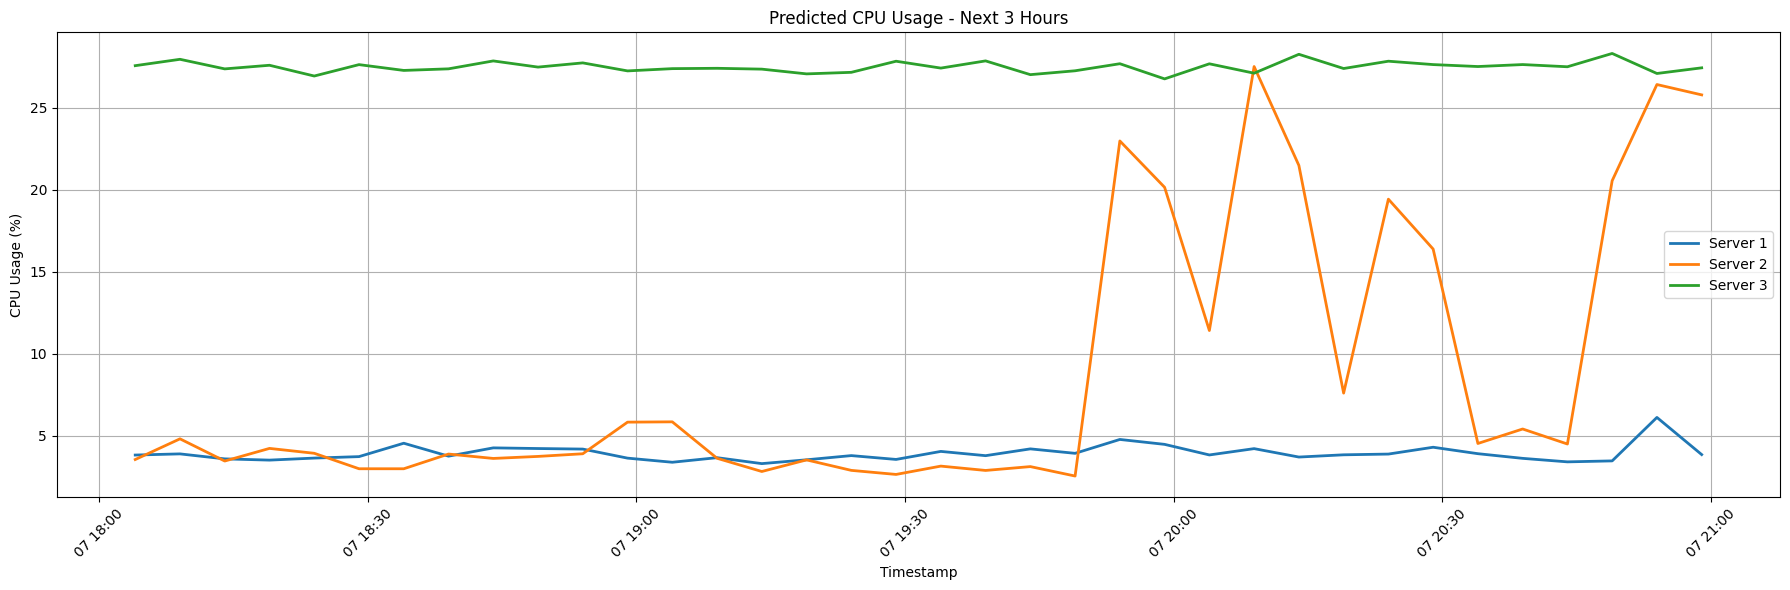

In [16]:
# ==========================================
# CPU Prediction Plot
# ==========================================

plt.figure(figsize=(18,6))

for sid in sorted(results["host_id"].unique()):

    temp = results[
        results["host_id"] == sid
    ]

    plt.plot(

        temp["timestamp"],

        temp["predicted_cpu_usage"],

        linewidth=2,

        label=f"Server {sid}"

    )

plt.title("Predicted CPU Usage - Next 3 Hours")

plt.xlabel("Timestamp")

plt.ylabel("CPU Usage (%)")

plt.grid(True)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

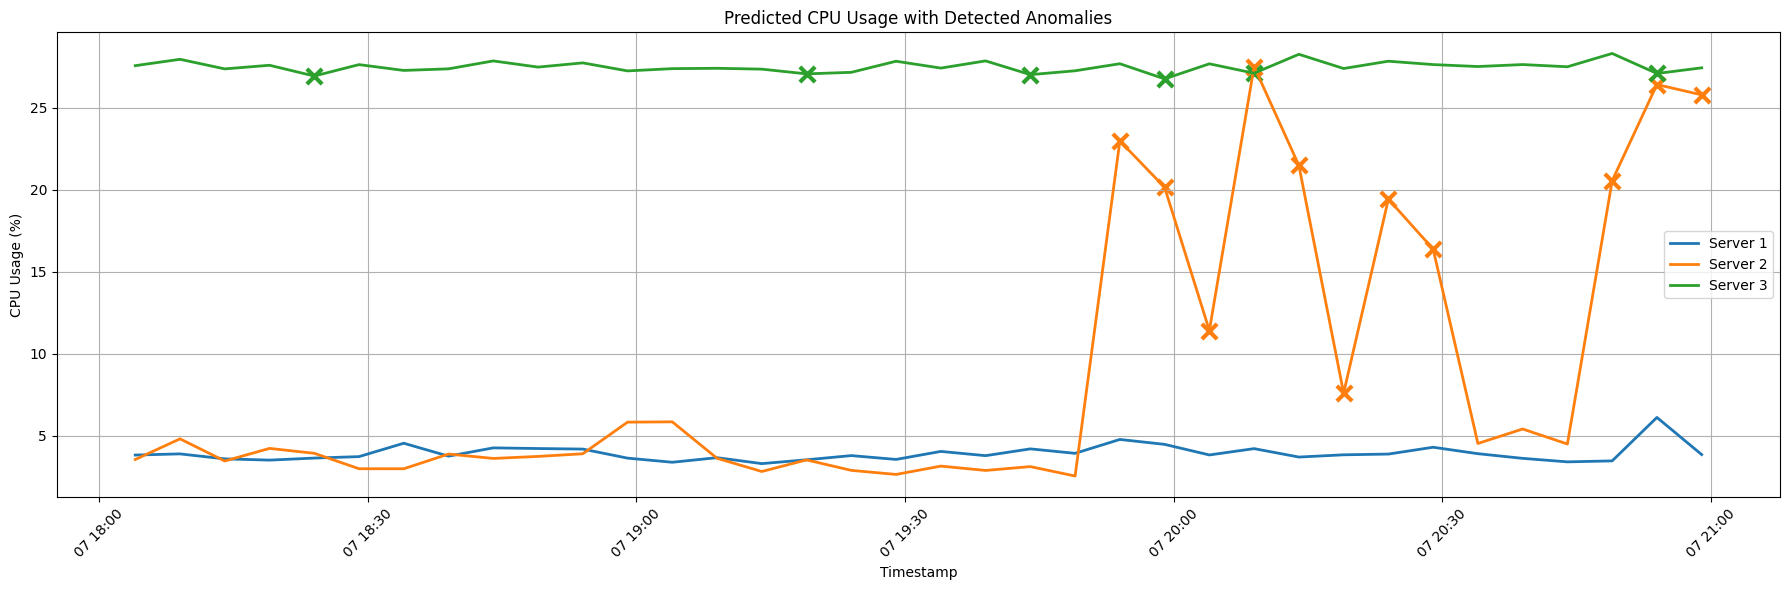

In [17]:
# ==========================================
# Plot Predicted Anomalies
# ==========================================

plt.figure(figsize=(18,6))

for sid in sorted(results["host_id"].unique()):

    temp = results[
        results["host_id"] == sid
    ]

    plt.plot(

        temp["timestamp"],

        temp["predicted_cpu_usage"],

        linewidth=2,

        label=f"Server {sid}"

    )

    anomaly = temp[
        temp["status"] == "Anomaly"
    ]

    plt.scatter(

        anomaly["timestamp"],

        anomaly["predicted_cpu_usage"],

        marker="x",

        s=120,

        linewidths=3

    )

plt.title("Predicted CPU Usage with Detected Anomalies")

plt.xlabel("Timestamp")

plt.ylabel("CPU Usage (%)")

plt.grid(True)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [18]:
# ==========================================
# Export Anomalies
# ==========================================

anomalies = results[
    results["status"] == "Anomaly"
].copy()

ANOMALY_FILE = OUTPUT_DIR / "predicted_anomalies.csv"

anomalies.to_csv(
    ANOMALY_FILE,
    index=False
)

print(anomalies)

print(f"\nSaved : {ANOMALY_FILE}")

     host_id                 timestamp  predicted_cpu_usage   status
58         2 2026-07-07 19:54:00+00:00            22.965286  Anomaly
59         2 2026-07-07 19:59:00+00:00            20.138227  Anomaly
60         2 2026-07-07 20:04:00+00:00            11.406838  Anomaly
61         2 2026-07-07 20:09:00+00:00            27.501545  Anomaly
62         2 2026-07-07 20:14:00+00:00            21.473246  Anomaly
63         2 2026-07-07 20:19:00+00:00             7.591181  Anomaly
64         2 2026-07-07 20:24:00+00:00            19.416304  Anomaly
65         2 2026-07-07 20:29:00+00:00            16.373350  Anomaly
69         2 2026-07-07 20:49:00+00:00            20.539225  Anomaly
70         2 2026-07-07 20:54:00+00:00            26.404795  Anomaly
71         2 2026-07-07 20:59:00+00:00            25.774166  Anomaly
76         3 2026-07-07 18:24:00+00:00            26.923580  Anomaly
87         3 2026-07-07 19:19:00+00:00            27.054426  Anomaly
92         3 2026-07-07 19:44:00+0

In [19]:
# ==========================================
# Server-wise Prediction Summary
# ==========================================

summary = (
    results
    .groupby("host_id")
    .agg(
        Average_CPU=("predicted_cpu_usage", "mean"),
        Maximum_CPU=("predicted_cpu_usage", "max"),
        Minimum_CPU=("predicted_cpu_usage", "min"),
        Total_Predictions=("predicted_cpu_usage", "count")
    )
    .reset_index()
)

summary["Average_CPU"] = summary["Average_CPU"].round(2)
summary["Maximum_CPU"] = summary["Maximum_CPU"].round(2)
summary["Minimum_CPU"] = summary["Minimum_CPU"].round(2)

print(summary)

   host_id  Average_CPU  Maximum_CPU  Minimum_CPU  Total_Predictions
0        1         3.92     6.110000         3.29                 36
1        2         8.72    27.500000         2.54                 36
2        3        27.48    28.299999        26.75                 36


In [20]:
# ==========================================
# Anomaly Summary
# ==========================================

anomaly_summary = (
    results
    .groupby("host_id")["status"]
    .value_counts()
    .unstack(fill_value=0)
)

print(anomaly_summary)

status   Anomaly  Normal
host_id                 
1              0      36
2             11      25
3              6      30


In [21]:
# ==========================================
# Server Risk Level
# ==========================================

risk = (
    results
    .groupby("host_id")["status"]
    .apply(lambda x: (x == "Anomaly").sum())
    .reset_index(name="Anomaly_Count")
)

risk["Risk_Level"] = "Low"

risk.loc[
    risk["Anomaly_Count"] >= 5,
    "Risk_Level"
] = "Medium"

risk.loc[
    risk["Anomaly_Count"] >= 10,
    "Risk_Level"
] = "High"

print(risk)

   host_id  Anomaly_Count Risk_Level
0        1              0        Low
1        2             11       High
2        3              6     Medium


In [22]:
# ==========================================
# Dashboard Summary
# ==========================================

dashboard = summary.merge(
    risk,
    on="host_id"
)

dashboard

,host_id,Average_CPU,Maximum_CPU,Minimum_CPU,Total_Predictions,Anomaly_Count,Risk_Level
0,1,3.92,6.110000,3.29,36,0,Low
1,2,8.72,27.500000,2.54,36,11,High
2,3,27.48,28.299999,26.75,36,6,Medium


In [23]:
# ==========================================
# Save Dashboard Summary
# ==========================================

dashboard.to_csv(

    OUTPUT_DIR / "dashboard_summary.csv",

    index=False

)

print("Dashboard Summary Saved")

Dashboard Summary Saved


In [24]:
print("="*60)
print("CPU Predictive Maintenance Inference Completed")
print("="*60)

print()

print("Generated Files")

print("----------------")

print("cpu_predictions.csv")

print("predicted_anomalies.csv")

print("dashboard_summary.csv")

CPU Predictive Maintenance Inference Completed

Generated Files
----------------
cpu_predictions.csv
predicted_anomalies.csv
dashboard_summary.csv
